# Test 02: Supervised and Unsupervised Learning

Name: Lon Cherryholmes, Sr.

Date: Friday 12/05/2025

CWID: xxx17840

You need to get the questions from our class MyLeoOnline site by starting Test 02.  You should be given 2 multi-part questions.

Please make sure that the notebook that you submit for grading runs all cells cleanly from top to bottom if a **Run -> Run All Cells** is performed.  Please give your name and CWID in the provided fields below to ensure your test work is properly attributed.  As a reminder, all work on tests and assignments for this class is individual work unless otherwise noted.  You may not work with others, nor use past student's works or answers created by others for these test questions.

## General Setup

The following imports may be useful for Test 02, and should be sufficient to finish the
questions.  However, if you would like to import additional functions or objects, you may
do so, though they need to come from `scikit-learn` library, or other functions from basic
libraries like `numpy`, `matplotlib` or `pandas`.

In [244]:
# Basic imports that are generally useful
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
import matplotlib
import sklearn

# Imports specific to these test questions
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Please put all imports you add for your work here
import IPython
from pprint import pprint, pformat
from pandas.plotting import scatter_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LinearRegression

In [245]:
# Notebook-wide options to improve appearance of basic matplotlib figures and numpy output
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10, 8) # set default figure size, 10in by 8in
np.set_printoptions(suppress=True)
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('figure', titlesize=18)
plt.rc('legend', fontsize=14)
plt.rcParams['figure.figsize'] = (12.0, 8.0) # default figure size if not specified in plot

# Please put all options you add for your work here
pd.set_option("display.max_colwidth", 20)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
np.set_printoptions(linewidth=120, precision=3)

Start Test 02 in MyLeoOnline to get the test questions you need to answer.  You will need
to use the `wine` dataset.  In addition to this notebook, you should have been given
a `wine.csv` file to download for use on this question.  Please put the file
into the same directory as where you run your notebook and do not use an absolute
path name in your command to load the file into a Pandas dataframe or NumPy array.

In [246]:
loaded_wine = load_wine()
print(loaded_wine.data.shape)
print(loaded_wine.feature_names)
print(loaded_wine.frame)
print(loaded_wine.target.shape)
print(loaded_wine.target_names)
print(loaded_wine.DESCR)

(178, 13)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
None
(178,)
['class_0' 'class_1' 'class_2']
.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:  

## Data Acquisition and Exploration

In [247]:
ipython = IPython.get_ipython()
if "ColabKernelApp" in ipython.config:
    print("Currently running in Colab!")
    from google.colab import drive
    drive.mount('/content/modules', force_remount=False)
    import os
    os.chdir("/content/modules/My Drive/CSCI-574")

Currently running in Colab!
Drive already mounted at /content/modules; to attempt to forcibly remount, call drive.mount("/content/modules", force_remount=True).


In [248]:
def quality_rank(q):
    if q >= 7:    return 1 # premium
    elif q >= 5:  return 2 # good
    else:         return 3 # poor

In [249]:
wine = pd.read_csv("wine.csv", delimiter=';')
#wine["rank"] = wine["quality"].apply(quality_rank)

In [250]:
print(wine.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None


In [251]:
wine['quality'].value_counts()

,count
quality,
6,2198
5,1457
7,880
8,175
4,163
3,20
9,5


In [252]:
#wine['rank'].value_counts()

In [253]:
display(wine.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


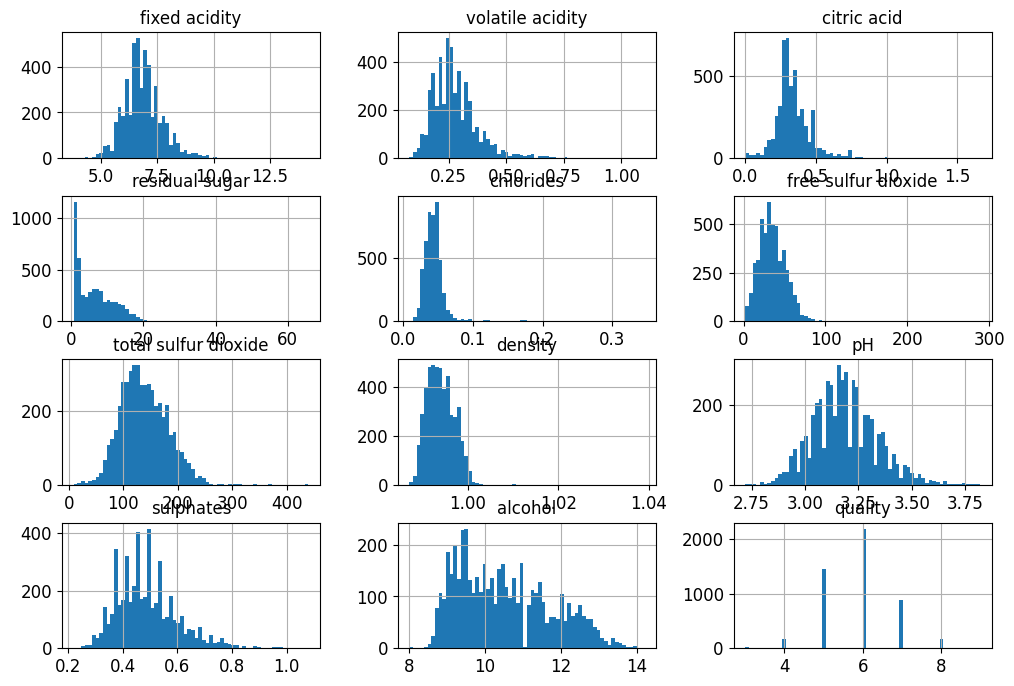

In [254]:
wine.hist(bins=64, figsize=(12,8));

In [255]:
wine_corr = wine.corr()
print(wine_corr['quality'].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.435575
pH                      0.099427
sulphates               0.053678
free sulfur dioxide     0.008158
citric acid            -0.009209
residual sugar         -0.097577
fixed acidity          -0.113663
total sulfur dioxide   -0.174737
volatile acidity       -0.194723
chlorides              -0.209934
density                -0.307123
Name: quality, dtype: float64


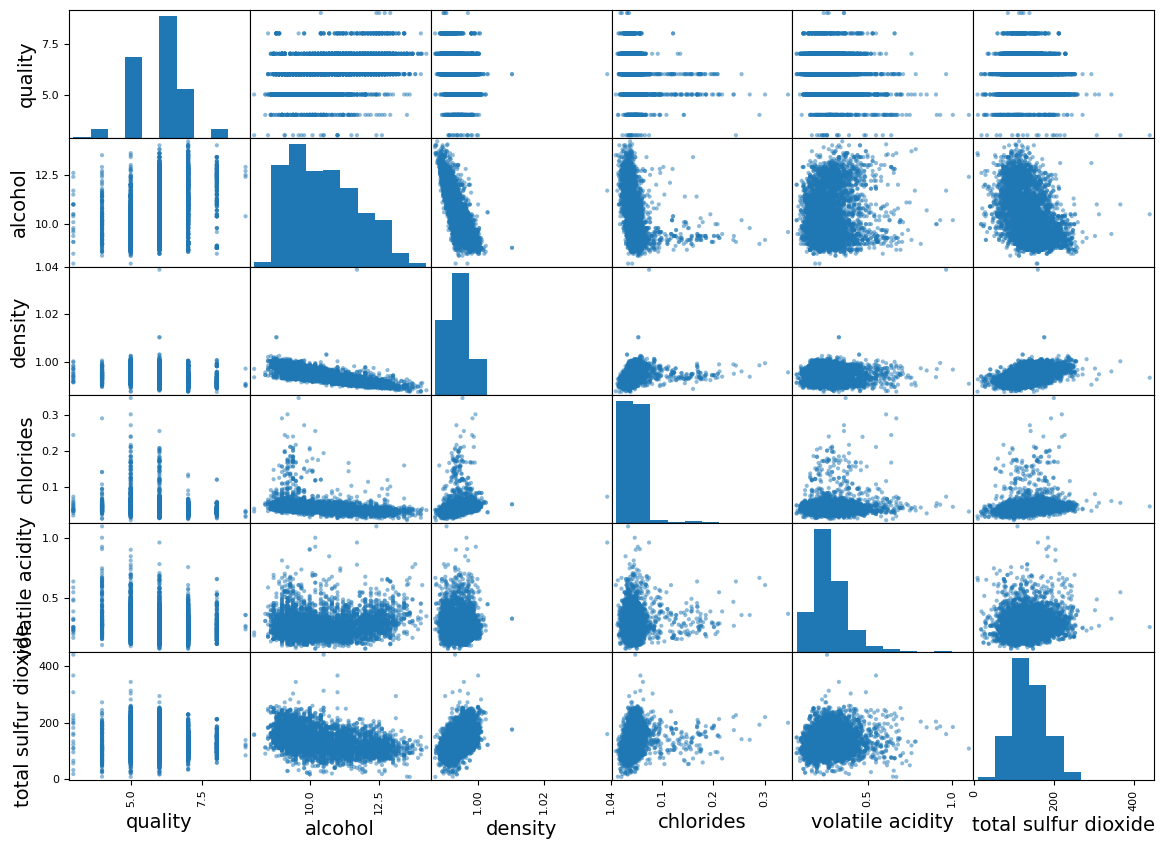

In [256]:
scatter_matrix(wine[['quality', 'alcohol', 'density', 'chlorides', 'volatile acidity', 'total sulfur dioxide']], figsize=(14,10));

## Set Target feature

In [257]:
TARGET = 'quality' # 'rank'

## Prep 1: Supervised Learning

In [258]:
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(wine, wine[TARGET]):
    strat_splits.append([wine.iloc[train_index], wine.iloc[test_index]])

In [259]:
print(wine[TARGET].value_counts() / len(wine))
pprint([(w[TARGET].value_counts() / len(w)).to_numpy() for w, _ in strat_splits])

quality
6    0.448755
5    0.297468
7    0.179665
8    0.035729
4    0.033279
3    0.004083
9    0.001021
Name: count, dtype: float64
[array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001]),
 array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001]),
 array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001]),
 array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001]),
 array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001]),
 array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001]),
 array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001]),
 array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001]),
 array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001]),
 array([0.449, 0.298, 0.18 , 0.036, 0.033, 0.004, 0.001])]


In [260]:
wine_train, wine_test = strat_splits[0]
print(wine_train.shape)
print(wine_test.shape)
X_train = wine_train.iloc[:, 0:11].to_numpy()
y_train = wine_train.loc[:, TARGET].to_numpy()
X_test  = wine_test.iloc[:, 0:11].to_numpy()
y_test  = wine_test.loc[:, TARGET].to_numpy()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3918, 12)
(980, 12)
(3918, 11) (3918,)
(980, 11) (980,)


0.5459183673469388


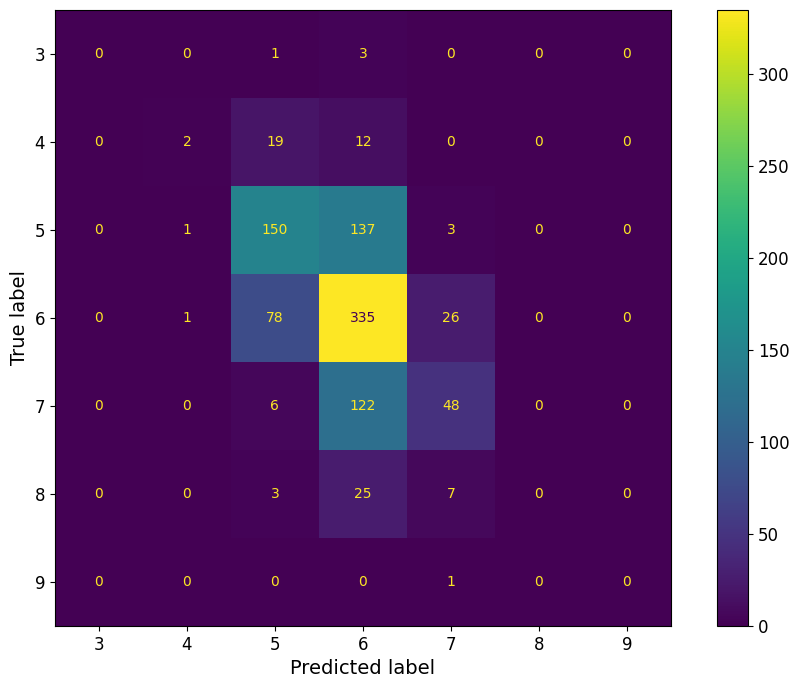

In [261]:
transformer = StandardScaler()
X_train_scaled = transformer.fit_transform(X_train)
X_test_scaled = transformer.fit_transform(X_test)
model = LogisticRegression(penalty='l2')
model.fit(X_train_scaled, y_train)
y_test_pred = model.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
print(model.score(X_test_scaled, y_test))

0.5591836734693878


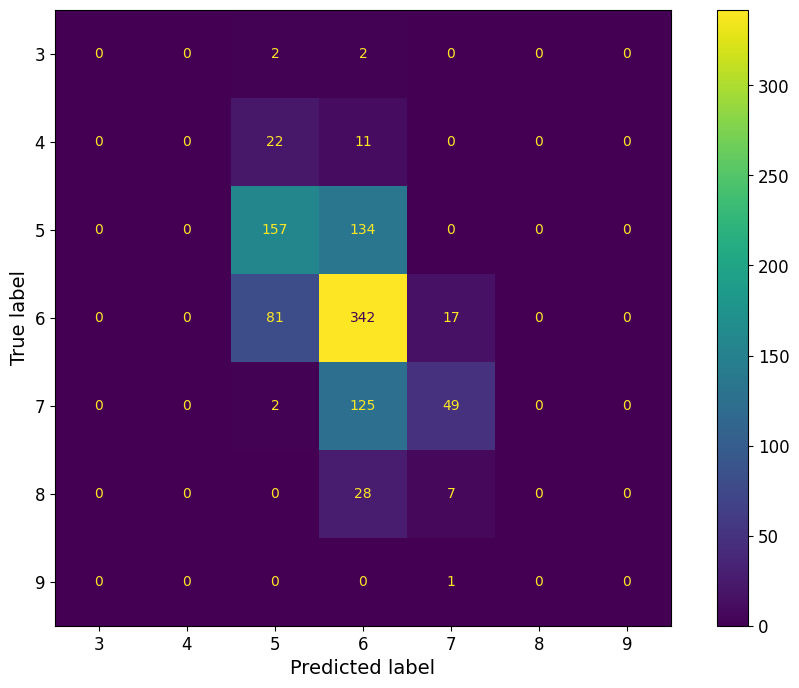

In [262]:
transformer = StandardScaler()
X_train_scaled = transformer.fit_transform(X_train)
X_test_scaled = transformer.fit_transform(X_test)
model = SVC()
model.fit(X_train_scaled, y_train)
y_test_pred = model.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
print(model.score(X_test_scaled, y_test))

0.6642857142857143


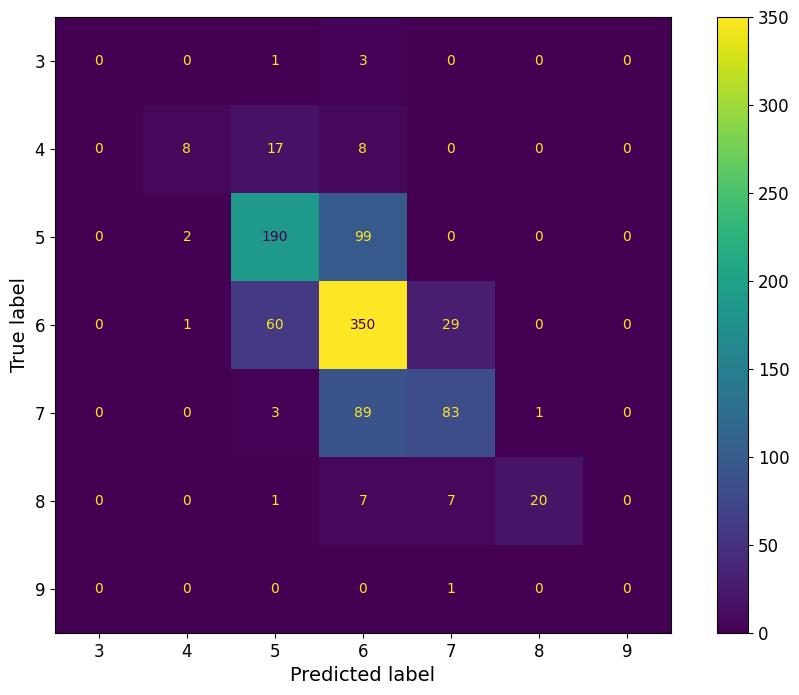

In [263]:
model = ExtraTreesClassifier()
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
print(model.score(X_test, y_test))

In [264]:
"""
pipe = Pipeline([
    ('pre', StandardScaler()),
    ('clf', LogisticRegression())
])
pipe.fit(X_train, y_train)
y_test_pred = pipe.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
grid_params = [
    { 'clf__solver': ['lbfgs', 'newton-cholesky', 'newton-cg'],
      'clf__penalty': [None, 'l2'],
      'clf__max_iter': [512],
      'clf__class_weight': [None, 'balanced']
    },
    { 'clf__solver': ['liblinear'],
      'clf__penalty': ['l1', 'l2'],
      'clf__max_iter': [512],
      'clf__class_weight': [None, 'balanced']
    },
    { 'clf__solver': ['saga'],
      'clf__penalty': [None, 'l1', 'l2'],
      'clf__max_iter': [2048],
      'clf__class_weight': [None, 'balanced']
    },
    { 'clf__solver': ['saga'],
      'clf__penalty': ['elasticnet'],
      'clf__max_iter': [2048],
      'clf__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
      'clf__class_weight': [None, 'balanced']
    },
]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipe, grid_params, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)
"""

"\npipe = Pipeline([\n    ('pre', StandardScaler()),\n    ('clf', LogisticRegression())\n])\npipe.fit(X_train, y_train)\ny_test_pred = pipe.predict(X_test)\nConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)\ngrid_params = [\n    { 'clf__solver': ['lbfgs', 'newton-cholesky', 'newton-cg'],\n      'clf__penalty': [None, 'l2'],\n      'clf__max_iter': [512],\n      'clf__class_weight': [None, 'balanced']\n    },\n    { 'clf__solver': ['liblinear'],\n      'clf__penalty': ['l1', 'l2'],\n      'clf__max_iter': [512],\n      'clf__class_weight': [None, 'balanced']\n    },\n    { 'clf__solver': ['saga'],\n      'clf__penalty': [None, 'l1', 'l2'],\n      'clf__max_iter': [2048],\n      'clf__class_weight': [None, 'balanced']\n    },\n    { 'clf__solver': ['saga'],\n      'clf__penalty': ['elasticnet'],\n      'clf__max_iter': [2048],\n      'clf__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],\n      'clf__class_weight': [None, 'balanced']\n    },\n]\ncv = StratifiedKFold(n_splits=3, shuffle

In [265]:
X = wine.iloc[:, 0:11].to_numpy()
y = wine.loc[:, TARGET].to_numpy()
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, test_indices = next(splitter.split(X, y))
X_train, y_train = X[train_indices], y[train_indices]
X_test, y_test = X[test_indices], y[test_indices]
model = ExtraTreesClassifier(n_estimators=128, random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
feature_names = wine.columns.tolist()
feature_importances = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
for name, score in feature_importances:
    print(f"{name:>22s}: {score:.4f}")
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(model.score(X_test, y_test))

               alcohol: 0.1270
      volatile acidity: 0.1022
               density: 0.0936
   free sulfur dioxide: 0.0900
  total sulfur dioxide: 0.0866
        residual sugar: 0.0855
           citric acid: 0.0854
                    pH: 0.0850
             chlorides: 0.0828
             sulphates: 0.0812
         fixed acidity: 0.0809
[[  0   1   1   2   0   0   0]
 [  0   7  18   8   0   0   0]
 [  0   4 186 100   1   0   0]
 [  0   1  60 351  28   0   0]
 [  0   0   3  87  85   1   0]
 [  0   0   1   8   6  20   0]
 [  0   0   0   0   1   0   0]]
0.6622448979591836


In [266]:
logistic_pipe = Pipeline([
    ("pre", StandardScaler()),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=512))
])
logistic_pipe.fit(X_train, y_train)
y_logistic_pred = logistic_pipe.predict(X_test)
print(confusion_matrix(y_test, y_logistic_pred))
print(logistic_pipe.score(X_test, y_test))
svc_pipe = Pipeline([
    ("pre", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=1.0))
])
svc_pipe.fit(X_train, y_train)
y_svc_pred = svc_pipe.predict(X_test)
print(confusion_matrix(y_test, y_svc_pred))
print(svc_pipe.score(X_test, y_test))

[[  0   0   1   3   0   0   0]
 [  0   2  19  12   0   0   0]
 [  0   1 153 134   3   0   0]
 [  0   1  78 335  26   0   0]
 [  0   0   6 122  48   0   0]
 [  0   0   3  25   7   0   0]
 [  0   0   0   0   1   0   0]]
0.5489795918367347
[[  0   0   1   3   0   0   0]
 [  0   1  22  10   0   0   0]
 [  0   0 160 131   0   0   0]
 [  0   0  81 340  19   0   0]
 [  0   0   3 119  54   0   0]
 [  0   0   0  27   8   0   0]
 [  0   0   0   0   1   0   0]]
0.5663265306122449


## Question 1: Supervised Learning (65 pts)

### Question 1.1: Load and Visualize Data

Perform the following tasks in separate code cells in the notebook you create to submit for Test 02.

Load the data from the file named wine.csv into a Pandas dataframe (from the '../data/wine.csv' directory) and print the shape of the data. The file is a csv file but does not use the normal commas, so you will need to specify some parameters to read it correctly. It should end up with 12 columns/features.

- Display the inferred types of each of the features you read in.
- Display a summary of the numerical features.
- Display the first 10 samples of the data.
- Display the distinct number of levels of the quality feature of this dataset.

In [267]:
print(wine.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None


In [268]:
print(wine.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar    chlorides  free sulfur dioxide  \
count    4898.000000       4898.000000  4898.000000     4898.000000  4898.000000          4898.000000   
mean        6.854788          0.278241     0.334192        6.391415     0.045772            35.308085   
std         0.843868          0.100795     0.121020        5.072058     0.021848            17.007137   
min         3.800000          0.080000     0.000000        0.600000     0.009000             2.000000   
25%         6.300000          0.210000     0.270000        1.700000     0.036000            23.000000   
50%         6.800000          0.260000     0.320000        5.200000     0.043000            34.000000   
75%         7.300000          0.320000     0.390000        9.900000     0.050000            46.000000   
max        14.200000          1.100000     1.660000       65.800000     0.346000           289.000000   

       total sulfur dioxide      density           pH 

In [269]:
display(wine.head(10))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
9,8.1,0.22,0.43,1.5,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6


In [270]:
print(wine['quality'].unique())
print(wine['quality'].value_counts())

[6 5 7 8 4 3 9]
quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64


### Question 1.2: Data Exploration and Visualization

- Calculate and display the correlation between all feature/columns of this data set.
- Create plot visualizing the two most highly correlated features. Display the raw features as scatter plot points.
- Fit a linear regression to these 2 features. Plot the resulting linear fit / model of these features on your same plot. (You can use any of the methods to fit a line to the data, e.g. NumPy polyfit, Scikit-Learn LinearRegression, etc.)

Make sure that you label your figure axis, and use the guidelines we discussed in class when producing the figure.

In [271]:
wine_corr = wine.corr()
print(np.min(wine_corr))
print(np.max(wine_corr))
display(wine_corr)

-0.7801376214255623
1.0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.022697,0.289181,0.089021,0.023086,-0.049396,0.091070,0.265331,-0.425858,-0.017143,-0.120881,-0.113663
volatile acidity,-0.022697,1.000000,-0.149472,0.064286,0.070512,-0.097012,0.089261,0.027114,-0.031915,-0.035728,0.067718,-0.194723
citric acid,0.289181,-0.149472,1.000000,0.094212,0.114364,0.094077,0.121131,0.149503,-0.163748,0.062331,-0.075729,-0.009209
residual sugar,0.089021,0.064286,0.094212,1.000000,0.088685,0.299098,0.401439,0.838966,-0.194133,-0.026664,-0.450631,-0.097577
chlorides,0.023086,0.070512,0.114364,0.088685,1.000000,0.101392,0.198910,0.257211,-0.090439,0.016763,-0.360189,-0.209934
free sulfur dioxide,-0.049396,-0.097012,0.094077,0.299098,0.101392,1.000000,0.615501,0.294210,-0.000618,0.059217,-0.250104,0.008158
total sulfur dioxide,0.091070,0.089261,0.121131,0.401439,0.198910,0.615501,1.000000,0.529881,0.002321,0.134562,-0.448892,-0.174737
density,0.265331,0.027114,0.149503,0.838966,0.257211,0.294210,0.529881,1.000000,-0.093591,0.074493,-0.780138,-0.307123
pH,-0.425858,-0.031915,-0.163748,-0.194133,-0.090439,-0.000618,0.002321,-0.093591,1.000000,0.155951,0.121432,0.099427
sulphates,-0.017143,-0.035728,0.062331,-0.026664,0.016763,0.059217,0.134562,0.074493,0.155951,1.000000,-0.017433,0.053678


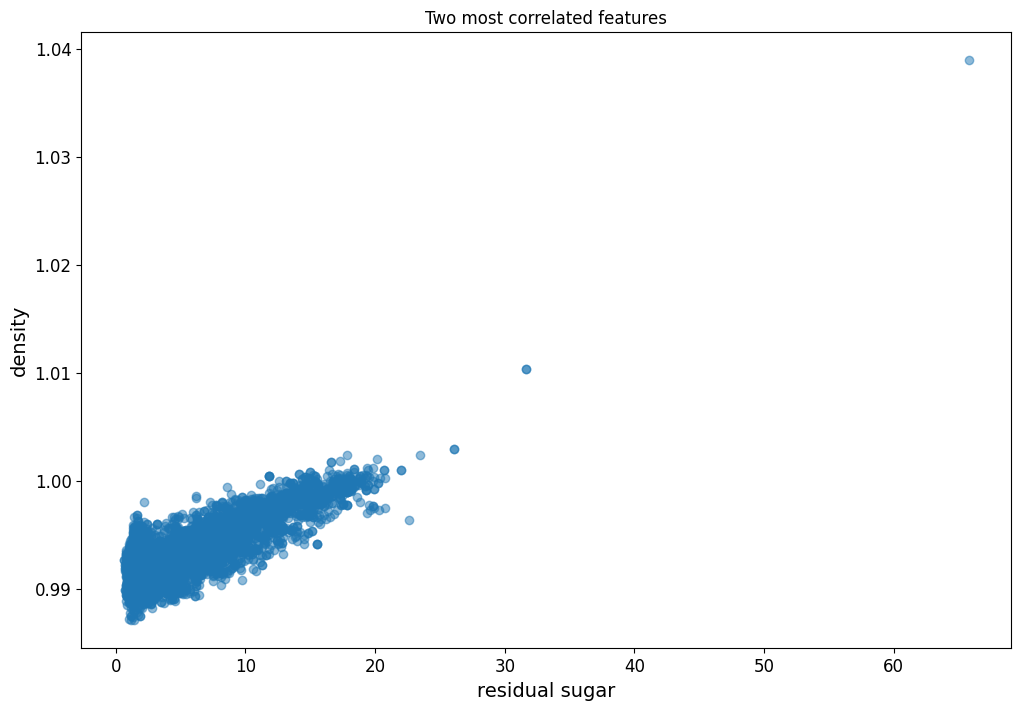

In [272]:
# residual sugar/density = 0.84
# free sulfur dioxide/total sulfur dioxide = 0.72
feature_1 = wine['residual sugar']
feature_2 = wine['density']
plt.scatter(feature_1, feature_2, alpha=0.5)
plt.xlabel("residual sugar")
plt.ylabel("density")
plt.title("Two most correlated features")
plt.show()

In [273]:
X1 = feature_1.to_numpy().reshape(-1, 1)
X2 = feature_2.to_numpy().reshape(-1, 1)
model = LinearRegression()
model.fit(X1, X2)
print(X1.shape)
print(X2.shape)
print(model.intercept_)
print(model.coef_)

(4898, 1)
(4898, 1)
[0.991]
[[0.]]


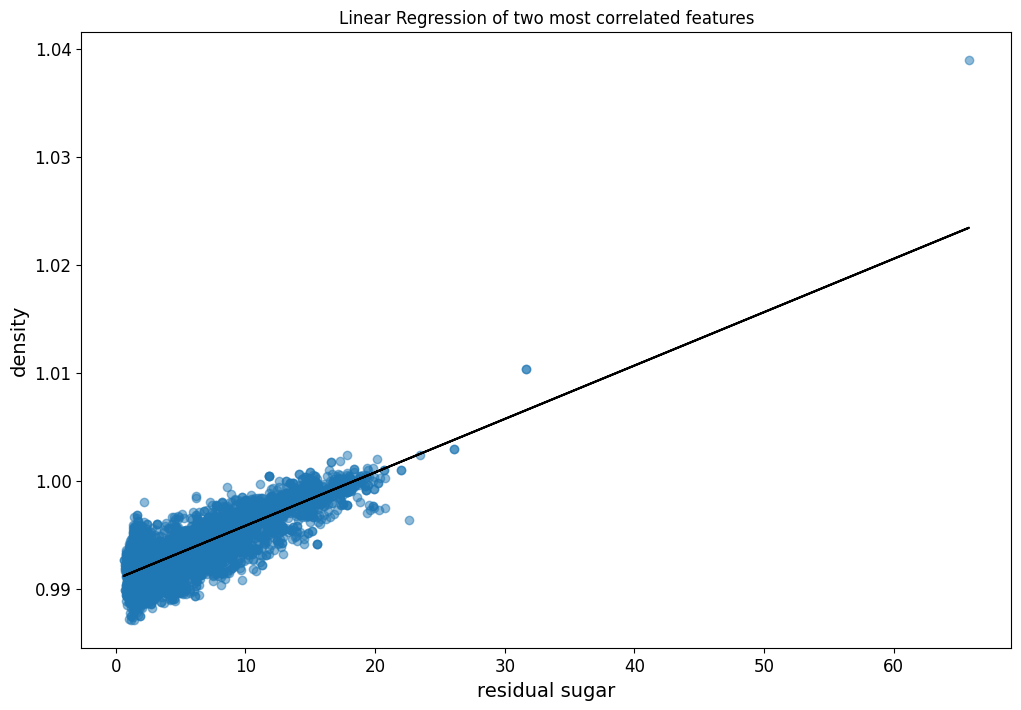

In [274]:
X2_pred = model.predict(X1)
plt.scatter(feature_1, feature_2, alpha=0.5)
plt.plot(X1, X2_pred, color='black', label="fitted linear regression")
plt.xlabel("residual sugar")
plt.ylabel("density")
plt.title("Linear Regression of two most correlated features")
plt.show()

### Question 1.3: Data Preparation

The quality feature of this data set is a categorical label. We want to build classifier predictors to be able to predict this feature.

Create NumPy arrays from the dataframe called X and y. The X array should have all of the input features. The y array will contain the categorical labels for our task. Report the shapes of your X and y NumPy arrays.

In [275]:
X = wine.iloc[:, 0:11].to_numpy()
y = wine.loc[:, TARGET].to_numpy()
print(X.shape)
print(y.shape)

(4898, 11)
(4898,)


In a previous step you should notice that the range of the X input features are not equally scaled. Some have very small relative, while others' ranges are large relative to other features.

- Scale all of the X inputs before we perform train/test split. Use a Standard Scaler. Display the min, max and mean of all of the input features, before and after you perform the standard scaling.

- Display / visualize a histogram of the y labels.

In [276]:
print(X.min(axis=0))
print(X.max(axis=0))
print(X.mean(axis=0))
transformer = StandardScaler()
X_scaled = transformer.fit_transform(X)
print(X_scaled.min(axis=0))
print(X_scaled.max(axis=0))
print(X_scaled.mean(axis=0))

[3.8   0.08  0.    0.6   0.009 2.    9.    0.987 2.72  0.22  8.   ]
[ 14.2     1.1     1.66   65.8     0.346 289.    440.      1.039   3.82    1.08   14.2  ]
[  6.855   0.278   0.334   6.391   0.046  35.308 138.361   0.994   3.188   0.49   10.514]
[-3.62  -1.967 -2.762 -1.142 -1.683 -1.959 -3.044 -2.313 -3.101 -2.365 -2.043]
[ 8.705  8.154 10.956 11.714 13.743 14.918  7.098 15.031  4.184  5.172  2.995]
[-0.  0.  0. -0.  0. -0. -0.  0. -0. -0. -0.]


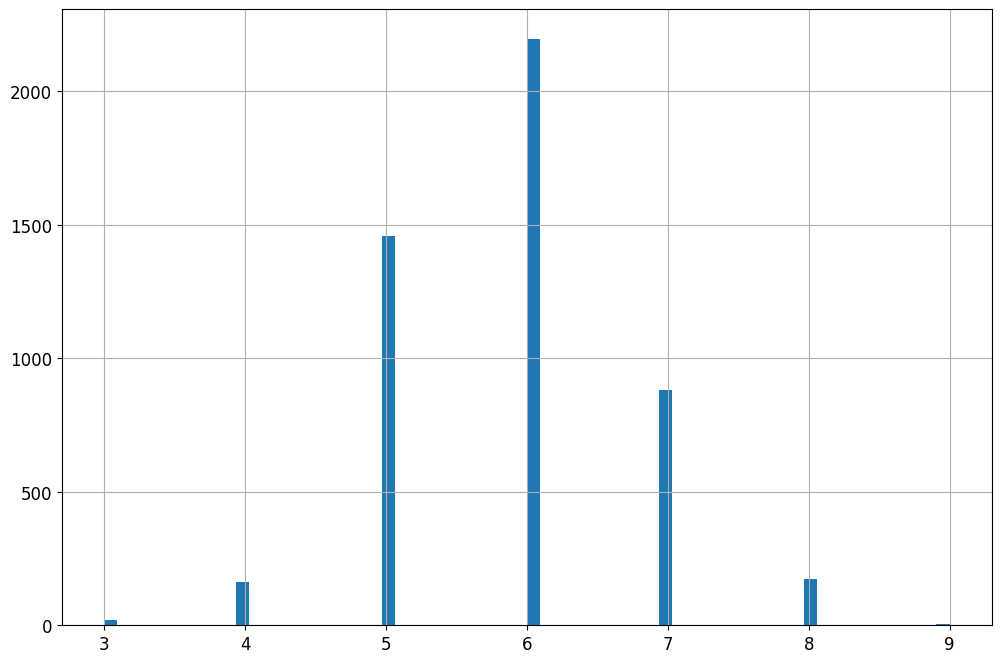

In [277]:
wine['quality'].hist(bins=64, figsize=(12,8));

You will find that the counts of the label categories are not evenly distributed. In fact the counts are roughly normally distributed, with most samples having a quality of 6, and very few samples have quality 3 or quality 9. Also if you look carefully at the y labels you will find that they are sorted, so we need to be careful when splitting the data.

We need to split the data into training and test data sets. But because of the uneven distribution of our label, we would like to perform a stratified split that will shuffle the data and split it so that we have roughly equal proportions of the quality label in both the training and test sets.

Split the data into training/test datasets. Use a 80% / 20% split of train/test sets respectively. Name these X_train, X_test for the inputs and y_train, y_test for the labels respectively. Report the shapes of all of the resulting NumPy arrays. Make sure your split shuffles the data and performs a stratified split of the data. Confirm this is the case for your datasets (for example showing a histogram again of the split labels would confirm this).

In [278]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, test_indices = next(splitter.split(X, y))
X_train, y_train = X[train_indices], y[train_indices]
X_test, y_test = X[test_indices], y[test_indices]

array([[<Axes: title={'center': 'quality'}>]], dtype=object)

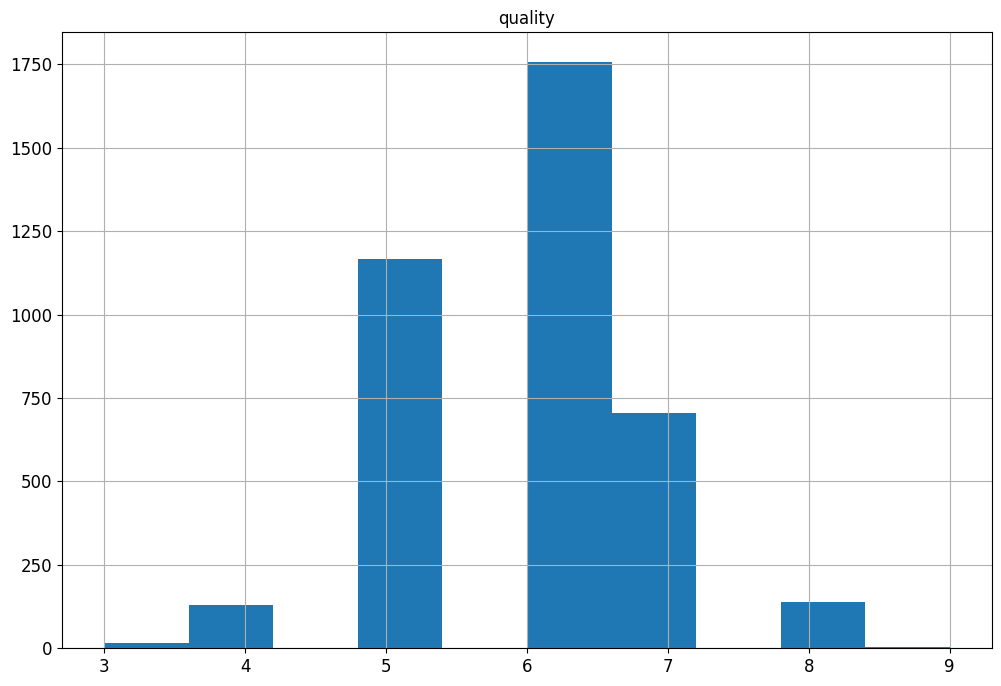

In [279]:
pd_y_train = pd.DataFrame(y_train, columns=['quality'])
pd_y_train.hist()

### Question 1.4 Train and Evaluate Classification Model

Demonstrate training and fitting a basic logistic regression classifier on this data sets training data. Recall that the default configuration of a logistic regression is to try and fine linear decision boundaries for the multiclass classification data here. Report the raw accuracy and show the confusion matrix of the performance of this model on the test data set. Note: Because logistic regression fits a linear decision boundary, you should not expect to get very good performance on this model.

In [280]:
transformer = StandardScaler()
X_train_scaled = transformer.fit_transform(X_train)
X_test_scaled = transformer.fit_transform(X_test)
model = LogisticRegression(penalty='l2')
model.fit(X_train_scaled, y_train)
y_test_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_test_pred))
print(model.score(X_test_scaled, y_test))

[[  0   0   1   3   0   0   0]
 [  0   2  19  12   0   0   0]
 [  0   1 150 137   3   0   0]
 [  0   1  78 335  26   0   0]
 [  0   0   6 122  48   0   0]
 [  0   0   3  25   7   0   0]
 [  0   0   0   0   1   0   0]]
0.5459183673469388


Train some sort of an ensemble tree classifier (like a random forest or extra trees model). Show the raw accuracy and confusion matrix performance again of this model. Try tuning this model to regularize it (so that it does not get perfect performance on the training data it is given). Does this improve its performance on the test data now?

In [281]:
model = ExtraTreesClassifier()
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_test_pred))
print(model.score(X_test, y_test))

[[  0   1   1   2   0   0   0]
 [  0   7  18   8   0   0   0]
 [  0   3 191  94   3   0   0]
 [  0   2  55 360  23   0   0]
 [  0   0   4  83  87   2   0]
 [  0   0   0   9   5  21   0]
 [  0   0   0   0   1   0   0]]
0.6795918367346939


In [282]:
pipe = Pipeline([
    ('clf', ExtraTreesClassifier())
])
pipe.fit(X_train, y_train)
y_test_pred = pipe.predict(X_test)
grid_params = [
    { 'clf__n_estimators': [1, 2, 4, 8, 16, 32],
      'clf__max_depth': [1, 2, 4, 8, 16],
    }
]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipe, grid_params, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'clf__max_depth': 16, 'clf__n_estimators': 32}
0.6357835630423686


## Prep 2: Unsupervised Learning

In [283]:
transformer = StandardScaler()
X = wine.iloc[:, 0:11].to_numpy()
y = wine.loc[:, TARGET].to_numpy()
X_scaled = transformer.fit_transform(X)
print(X_scaled.shape)

(4898, 11)


In [284]:
pca = PCA()
pca.fit(X_scaled)
print(pca.n_components_)
print(pca.components_)
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

11
[[ 0.157  0.005  0.144  0.427  0.212  0.3    0.407  0.512 -0.129  0.043 -0.437]
 [ 0.588 -0.052  0.345 -0.009  0.009 -0.29  -0.244 -0.006 -0.581 -0.223  0.036]
 [-0.121  0.591 -0.504  0.214  0.102 -0.279 -0.124  0.129 -0.127 -0.433 -0.106]
 [ 0.019  0.274  0.149 -0.274  0.711 -0.306 -0.06  -0.022  0.098  0.442 -0.141]
 [ 0.251  0.643  0.054  0.011 -0.329  0.177  0.293 -0.085 -0.12   0.401  0.337]
 [-0.104  0.122  0.132 -0.289  0.396  0.494  0.276 -0.328 -0.193 -0.481  0.139]
 [-0.198  0.269  0.705  0.213 -0.079 -0.167 -0.068  0.11   0.427 -0.309  0.129]
 [ 0.588  0.028 -0.152 -0.388 -0.1   -0.082  0.247  0.069  0.534 -0.27  -0.196]
 [ 0.331 -0.146 -0.202  0.409  0.394  0.144 -0.155  0.088  0.261 -0.012  0.621]
 [-0.132 -0.224 -0.037  0.094  0.053 -0.567  0.709 -0.068 -0.111 -0.058  0.273]
 [-0.171 -0.017 -0.01  -0.49  -0.025  0.031 -0.036  0.76  -0.141 -0.042  0.358]]
[3.223 1.576 1.222 1.019 0.974 0.939 0.727 0.599 0.414 0.29  0.021]
[0.293 0.143 0.111 0.093 0.088 0.085 0.066 0.054

In [285]:
pca = PCA(n_components=0.75)
Xd = pca.fit_transform(X_scaled)
print(pca.components_)
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

[[ 0.157  0.005  0.144  0.427  0.212  0.3    0.407  0.512 -0.129  0.043 -0.437]
 [ 0.588 -0.052  0.345 -0.009  0.009 -0.29  -0.244 -0.006 -0.581 -0.223  0.036]
 [-0.121  0.591 -0.504  0.214  0.102 -0.279 -0.124  0.129 -0.127 -0.433 -0.106]
 [ 0.019  0.274  0.149 -0.274  0.711 -0.306 -0.06  -0.022  0.098  0.442 -0.141]
 [ 0.251  0.643  0.054  0.011 -0.329  0.177  0.293 -0.085 -0.12   0.401  0.337]
 [-0.104  0.122  0.132 -0.289  0.396  0.494  0.276 -0.328 -0.193 -0.481  0.139]]
[3.223 1.576 1.222 1.019 0.974 0.939]
[0.293 0.143 0.111 0.093 0.088 0.085]


In [286]:
k = 7
kmeans = KMeans(n_clusters=k, n_init=3)
y_pred = kmeans.fit_predict(X_scaled)
print(y)
print(y_pred)
print(kmeans.cluster_centers_)

[6 6 6 ... 6 7 6]
[3 2 0 ... 0 6 6]
[[ 0.98  -0.313  0.32  -0.543 -0.268 -0.531 -0.528 -0.441 -0.69  -0.254  0.364]
 [-0.169  1.542 -1.022 -0.202  0.219 -0.553 -0.107  0.134 -0.002 -0.243 -0.562]
 [-0.469 -0.535 -0.135 -0.582 -0.1    0.004  0.015 -0.282  0.934  0.64   0.013]
 [-0.033 -0.377 -0.226  1.377  0.159  0.125  0.165  1.181 -0.317 -0.335 -0.829]
 [-0.182  0.308  0.943 -0.417  5.517  0.326  0.133  0.087 -0.608 -0.219 -0.776]
 [ 0.276  0.147  0.664  0.901  0.099  1.171  1.307  1.02  -0.252  0.283 -0.845]
 [-0.691  0.316 -0.266 -0.545 -0.537 -0.39  -0.754 -1.161  0.288 -0.284  1.381]]


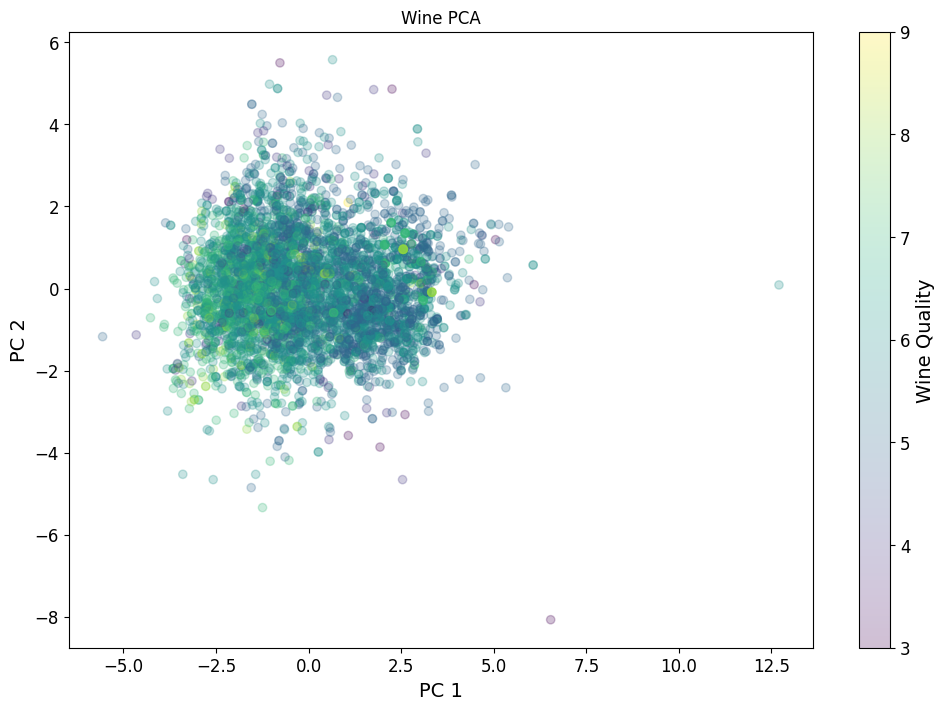

In [287]:
transformer = StandardScaler()
X_scaled = transformer.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", alpha=0.25)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Wine PCA")
plt.colorbar(label="Wine Quality")
plt.show()

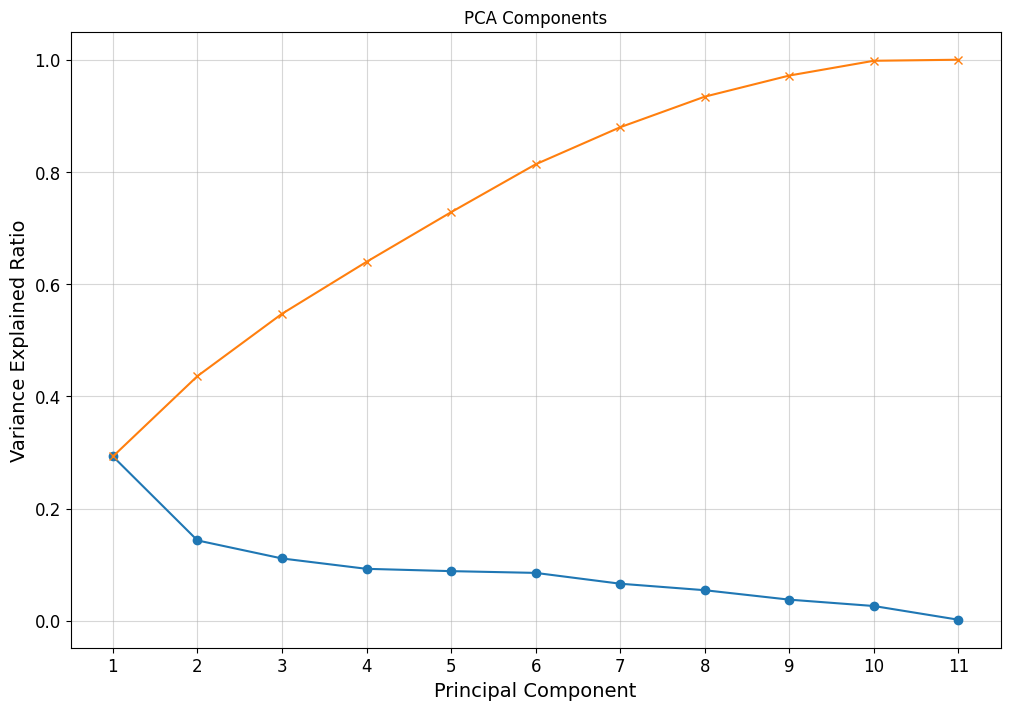

In [288]:
transformer = StandardScaler()
X_scaled = transformer.fit_transform(X)
pca = PCA(random_state=42)
pca.fit(X_scaled)
lngth = len(pca.explained_variance_ratio_)
plt.plot(range(1, lngth + 1), pca.explained_variance_ratio_, marker='o')
plt.plot(range(1, lngth + 1), np.cumsum(pca.explained_variance_ratio_), marker='x')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained Ratio")
plt.title("PCA Components")
plt.xticks(range(1, lngth + 1))
plt.grid(True, alpha=0.5)
plt.show()

In [289]:
loadings = pd.DataFrame(pca.components_[0:6].T, columns=["PC1","PC2","PC3","PC4","PC5","PC6"], index=wine.columns[0:11])
print(loadings)

                           PC1       PC2       PC3       PC4       PC5       PC6
fixed acidity         0.157218  0.587558 -0.121368  0.018584  0.251048 -0.103531
volatile acidity      0.005089 -0.051728  0.590971  0.274115  0.642617  0.122338
citric acid           0.144050  0.345295 -0.504397  0.148514  0.053905  0.132097
residual sugar        0.427408 -0.008749  0.214320 -0.273765  0.011391 -0.289447
chlorides             0.212011  0.008800  0.102367  0.710712 -0.328628  0.395821
free sulfur dioxide   0.300334 -0.290355 -0.279410 -0.305585  0.176912  0.494494
total sulfur dioxide  0.406652 -0.244032 -0.124375 -0.060456  0.293010  0.276320
density               0.511524 -0.006297  0.129203 -0.022061 -0.084588 -0.327651
pH                   -0.128832 -0.581344 -0.126672  0.097753 -0.119826 -0.193341
sulphates             0.043379 -0.222695 -0.433244  0.442060  0.400585 -0.481039
alcohol              -0.437238  0.035569 -0.105903 -0.141079  0.337419  0.139284


6
6
0.8136148733941037


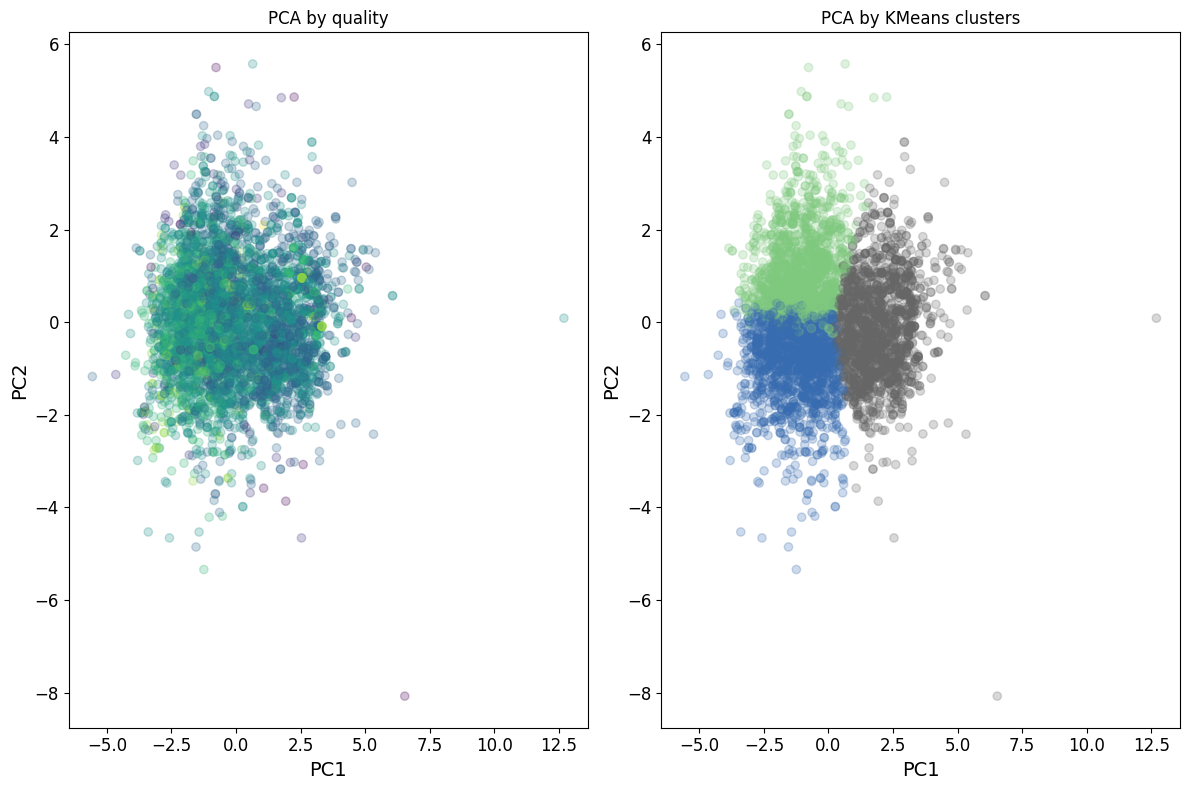

In [290]:
transformer = StandardScaler()
X_scaled = transformer.fit_transform(X)
pca_xd = PCA(n_components=0.80, random_state=42)
X_pca_xd = pca_xd.fit_transform(X_scaled)
print(pca_xd.n_components_)
print(X_pca_xd.shape[1])
print(pca_xd.explained_variance_ratio_.sum())
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_pca_xd)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
plt.subplot(1, 2, 1)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap="viridis", alpha=0.25)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA by quality")
plt.subplot(1, 2, 2)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters, cmap="Accent", alpha=0.25)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA by KMeans clusters")
plt.tight_layout()
plt.show()

In [291]:
"""
pipe = Pipeline([
    ("pre", StandardScaler()),
    ("pca", PCA()),
    ("clf", None)
])
param_grid = [
    {
        "pca__n_components": [5, 7, 9],
        "clf": [SVC()],
        "clf__kernel": ["linear", "rbf"],
        "clf__C": [0.1, 1, 10]
    },
    {
        "pca__n_components": [5, 7, 9],
        "clf": [LogisticRegression(max_iter=1024)],
        "clf__C": [0.1, 1, 10],
        "clf__penalty": ["l2"]
    }
]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring="accuracy")
grid_search.fit(X, y)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
"""

'\npipe = Pipeline([\n    ("pre", StandardScaler()),\n    ("pca", PCA()),\n    ("clf", None)\n])\nparam_grid = [\n    {\n        "pca__n_components": [5, 7, 9],\n        "clf": [SVC()],\n        "clf__kernel": ["linear", "rbf"],\n        "clf__C": [0.1, 1, 10]\n    },\n    {\n        "pca__n_components": [5, 7, 9],\n        "clf": [LogisticRegression(max_iter=1024)],\n        "clf__C": [0.1, 1, 10],\n        "clf__penalty": ["l2"]\n    }\n]\ncv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)\ngrid_search = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring="accuracy")\ngrid_search.fit(X, y)\nprint("Best params:", grid_search.best_params_)\nprint("Best score:", grid_search.best_score_)\n'

## Question 2: Unsupervised Learning (35 pts)

### Question 2.1 Dimensionality Reduction

Still using the wine dataset, perform a PCA and dimensionality reduction.  Perform the following tasks on all of the data in the wine dataset (e.g. do not use the train/test split data).

In [292]:
transformer = StandardScaler()
X = wine.iloc[:, 0:11].to_numpy()
y = wine.loc[:, TARGET].to_numpy()
X_scaled = transformer.fit_transform(X)
print(X_scaled.shape)

(4898, 11)


#### 2.1.1

Use PCA (principal component analysis) from scikit-learn on the whole dataset X that we have.

In [293]:
pca = PCA()
pca.fit(X_scaled)
print(pca.n_components_)
print(pca.components_)
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

11
[[ 0.157  0.005  0.144  0.427  0.212  0.3    0.407  0.512 -0.129  0.043 -0.437]
 [ 0.588 -0.052  0.345 -0.009  0.009 -0.29  -0.244 -0.006 -0.581 -0.223  0.036]
 [-0.121  0.591 -0.504  0.214  0.102 -0.279 -0.124  0.129 -0.127 -0.433 -0.106]
 [ 0.019  0.274  0.149 -0.274  0.711 -0.306 -0.06  -0.022  0.098  0.442 -0.141]
 [ 0.251  0.643  0.054  0.011 -0.329  0.177  0.293 -0.085 -0.12   0.401  0.337]
 [-0.104  0.122  0.132 -0.289  0.396  0.494  0.276 -0.328 -0.193 -0.481  0.139]
 [-0.198  0.269  0.705  0.213 -0.079 -0.167 -0.068  0.11   0.427 -0.309  0.129]
 [ 0.588  0.028 -0.152 -0.388 -0.1   -0.082  0.247  0.069  0.534 -0.27  -0.196]
 [ 0.331 -0.146 -0.202  0.409  0.394  0.144 -0.155  0.088  0.261 -0.012  0.621]
 [-0.132 -0.224 -0.037  0.094  0.053 -0.567  0.709 -0.068 -0.111 -0.058  0.273]
 [-0.171 -0.017 -0.01  -0.49  -0.025  0.031 -0.036  0.76  -0.141 -0.042  0.358]]
[3.223 1.576 1.222 1.019 0.974 0.939 0.727 0.599 0.414 0.29  0.021]
[0.293 0.143 0.111 0.093 0.088 0.085 0.066 0.054

#### 2.1.2

Plot the explained variance of the dimensions/features. You should have 11 dimensions/features in X if you have been using it correctly at this point. We demonstrated plotting the explained variance observed by PCA in our lecture notebooks and in our textbook.

You should find that about 80% of the variance is explained by the top 6 components (features 0 through 5).

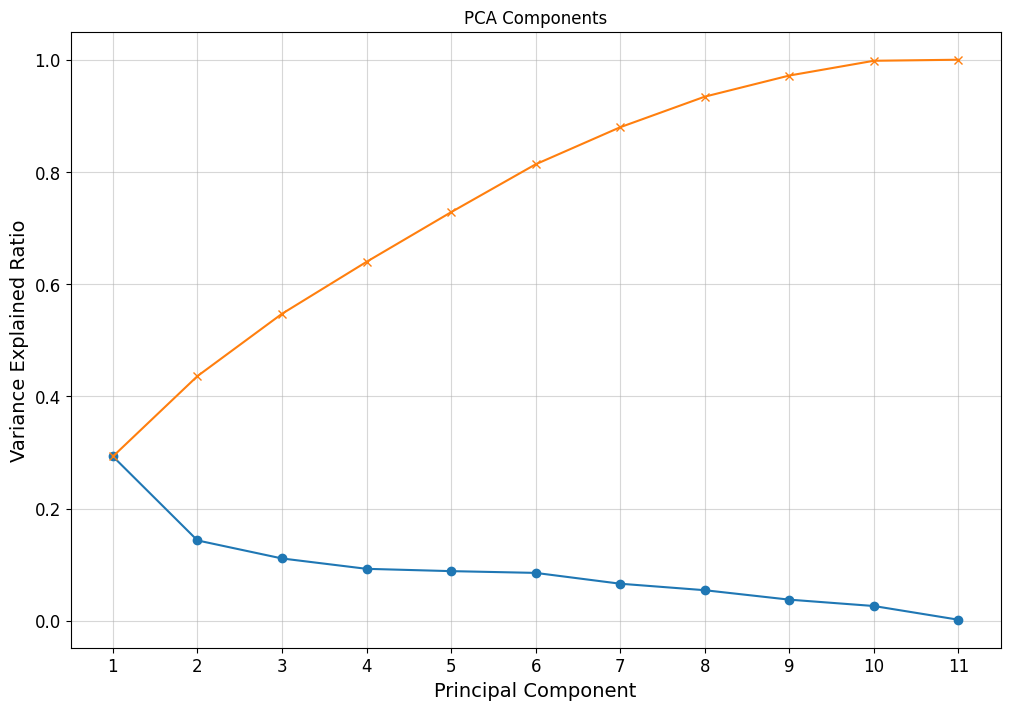

In [294]:
transformer = StandardScaler()
X_scaled = transformer.fit_transform(X)
pca = PCA(random_state=42)
pca.fit(X_scaled)
lngth = len(pca.explained_variance_ratio_)
plt.plot(range(1, lngth + 1), pca.explained_variance_ratio_, marker='o')
plt.plot(range(1, lngth + 1), np.cumsum(pca.explained_variance_ratio_), marker='x')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained Ratio")
plt.title("PCA Components")
plt.xticks(range(1, lngth + 1))
plt.grid(True, alpha=0.5)
plt.show()

#### 2.1.3

Fit PCA to all of the data X again, this time keeping only the components explaining the top 80% of the variance. Fit/transform a new set of X of reduced dimensions. Show the resulting shape of your transformed X (it should have 6 columns/features now).

In [295]:
pca = PCA(n_components=0.80)
Xd = pca.fit_transform(X_scaled)
print(pca.components_)
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)
print(Xd.shape)

[[ 0.157  0.005  0.144  0.427  0.212  0.3    0.407  0.512 -0.129  0.043 -0.437]
 [ 0.588 -0.052  0.345 -0.009  0.009 -0.29  -0.244 -0.006 -0.581 -0.223  0.036]
 [-0.121  0.591 -0.504  0.214  0.102 -0.279 -0.124  0.129 -0.127 -0.433 -0.106]
 [ 0.019  0.274  0.149 -0.274  0.711 -0.306 -0.06  -0.022  0.098  0.442 -0.141]
 [ 0.251  0.643  0.054  0.011 -0.329  0.177  0.293 -0.085 -0.12   0.401  0.337]
 [-0.104  0.122  0.132 -0.289  0.396  0.494  0.276 -0.328 -0.193 -0.481  0.139]]
[3.223 1.576 1.222 1.019 0.974 0.939]
[0.293 0.143 0.111 0.093 0.088 0.085]
(4898, 6)


#### 2.1.4

Resplit your reduced X data into train and test data the same as before (e.g. using a statified shuffle split with 80% training and 20% testing data).

In [296]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, test_indices = next(splitter.split(Xd, y))
X_train, y_train = X[train_indices], y[train_indices]
X_test, y_test = X[test_indices], y[test_indices]

#### 2.1.5

Train a new ensemble tree classifier again on this reduced dimensionality training data. Use the same one you did at the end of part 1 of this test, though you might want to try and tune your metaparameters again a bit. Display the raw accuracy on the test data and the confusion matrix of this classifiers performance.

In [297]:
pipe = Pipeline([
    ('clf', ExtraTreesClassifier())
])
pipe.fit(X_train, y_train)
y_test_pred = pipe.predict(X_test)
grid_params = [
    { 'clf__n_estimators': [1, 2, 4, 8, 16, 32],
      'clf__max_depth': [1, 2, 4, 8, 16],
    }
]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipe, grid_params, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'clf__max_depth': 16, 'clf__n_estimators': 32}
0.6403777437468097


In [298]:
model = ExtraTreesClassifier()
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_test_pred))
print(model.score(X_test, y_test))

[[  0   0   1   3   0   0   0]
 [  0   7  15  11   0   0   0]
 [  0   2 185 101   3   0   0]
 [  0   2  58 350  30   0   0]
 [  0   0   4  86  86   0   0]
 [  0   0   0   9   6  20   0]
 [  0   0   0   0   1   0   0]]
0.6612244897959184
